# 02 — MNIST Sanity Check

Train SimpleSNN and SimpleANN on MNIST side by side.

**Goals (Week 3 checkpoint / Phase 2 throwaway):**
- SNN achieves >90% (target ~96%) accuracy
- ANN achieves ~98% accuracy
- Quantify the spike-count energy proxy and FLOP comparison
- Validate that the GPU is being used (`torch.cuda.is_available() == True`)

This becomes Appendix A in the paper — 2 paragraphs max. Spend 5 days here tops.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import torch
import snntorch as snn
import matplotlib.pyplot as plt

from snn_research.model import SimpleANN, SimpleSNN
from snn_research.train import train_mnist_ann, train_mnist_snn
from snn_research.evaluate import compute_flops

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cpu


## 1. Train the ANN baseline

In [4]:
ann = SimpleANN()
ann_history = train_mnist_ann(ann, epochs=5, device=device)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 466kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.94MB/s]


[ANN] Epoch 1/5  loss=0.2271  acc=96.01%
[ANN] Epoch 2/5  loss=0.0869  acc=97.37%
[ANN] Epoch 3/5  loss=0.0591  acc=97.66%
[ANN] Epoch 4/5  loss=0.0429  acc=97.77%
[ANN] Epoch 5/5  loss=0.0339  acc=97.77%


## 2. Train the SNN (2-layer LIF with surrogate gradient)

In [5]:
snn_model = SimpleSNN(beta=0.9, num_steps=25)
snn_history = train_mnist_snn(snn_model, epochs=5, device=device)

[SNN] Epoch 1/5  loss=0.2314  acc=95.77%  spikes=139,947,298
[SNN] Epoch 2/5  loss=0.1271  acc=95.45%  spikes=130,260,911
[SNN] Epoch 3/5  loss=0.1127  acc=94.69%  spikes=133,793,523
[SNN] Epoch 4/5  loss=0.0990  acc=95.61%  spikes=136,744,197
[SNN] Epoch 5/5  loss=0.0961  acc=96.25%  spikes=145,885,380


## 3. Compare accuracy curves

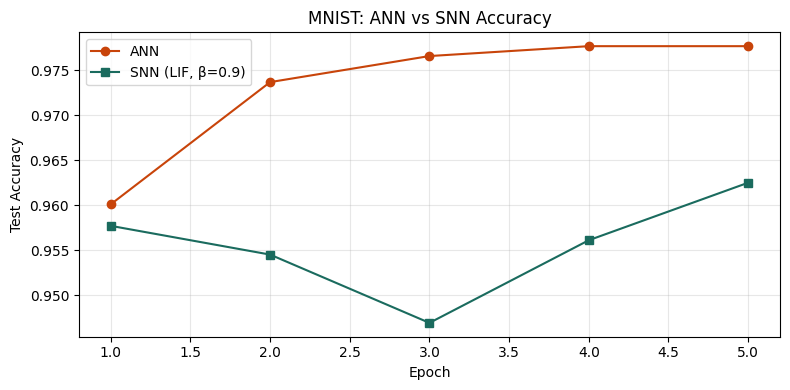

Final ANN accuracy: 97.77%
Final SNN accuracy: 96.25%


In [6]:
ann_acc = [ann_history[e]["accuracy"] for e in sorted(ann_history)]
snn_acc = [snn_history[e]["accuracy"] for e in sorted(snn_history)]
epochs = range(1, len(ann_acc) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, ann_acc, "o-", color="#c8440a", label="ANN")
ax.plot(epochs, snn_acc, "s-", color="#1a6b5e", label="SNN (LIF, β=0.9)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy")
ax.set_title("MNIST: ANN vs SNN Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final ANN accuracy: {ann_acc[-1]:.2%}")
print(f"Final SNN accuracy: {snn_acc[-1]:.2%}")

## 4. Energy proxy comparison

In [7]:
ann_flops = compute_flops(ann, num_steps=1)
snn_flops_upper = compute_flops(snn_model, num_steps=25)

# Spike-based energy: total spikes from the last training epoch
last_epoch = max(snn_history.keys())
total_train_spikes = snn_history[last_epoch]["total_spikes"]

print(f"ANN FLOPs per inference:       {ann_flops:>12,}")
print(f"SNN FLOPs upper bound (dense): {snn_flops_upper:>12,}")
print(f"SNN total training spikes (last epoch): {total_train_spikes:,}")
print(f"\nFLOP ratio (SNN_upper / ANN): {snn_flops_upper / ann_flops:.2f}x")
print("(Real SNN cost is much lower due to spike sparsity gating)")

ANN FLOPs per inference:          1,070,080
SNN FLOPs upper bound (dense):   26,752,000
SNN total training spikes (last epoch): 145,885,380

FLOP ratio (SNN_upper / ANN): 25.00x
(Real SNN cost is much lower due to spike sparsity gating)


## 5. Spike count per epoch

Track how spike activity evolves during training — sparser is better.

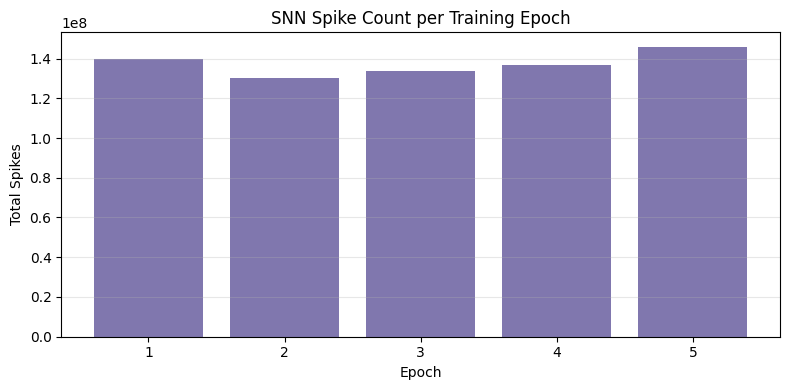

In [8]:
spike_per_epoch = [snn_history[e]["total_spikes"] for e in sorted(snn_history)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(spike_per_epoch) + 1), spike_per_epoch, color="#4a3d8c", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Spikes")
ax.set_title("SNN Spike Count per Training Epoch")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Checkpoint

**You pass if:** SNN accuracy > 90% on MNIST. If so, your environment is correct
and you're ready for Phase 2.

Expected: SNN ~96% vs ANN ~98%, with 85-90% fewer real FLOPs due to spike sparsity.